In [2]:
# %%
import os
import re
import yaml
import numpy as np
import xarray as xr
import xesmf as xe
import matplotlib.pyplot as plt

import sys
sys.path.append("HCtFlood")
from HCtFlood import kara as flood

# local modules (adjust if notebook is not in same folder as script)
from depths import vgrid_to_layers
sys.path.append("../boundary")
from boundary_nep import rotate_uv, rotate_uv_model_to_earth

plt.rcParams["figure.figsize"] = (10, 4)

# %% [markdown]
# ## 1) User inputs (config)
# Paste your YAML path here.

# %%
CONFIG_FILE = "nep_ic_dmi.yaml"

with open(CONFIG_FILE, "r") as f:
    cfg = yaml.safe_load(f)

with open(CONFIG_FILE, "r") as f:
    cfg = yaml.safe_load(f)

glorys_file   = cfg["glorys_file"]
vgrid_file    = cfg["vgrid_file"]
grid_file     = cfg["grid_file"]        # CGOA ocean_hgrid.nc
grid_file_nep = cfg["grid_file_nep"]    # NEP supergrid ocean_hgrid.nc
static_nep    = cfg["static_nep"]        # NEP_ocean_static_nomask.nc
output_file   = cfg["output_file"]
reuse_weights = cfg.get("reuse_weights", False)

varmap   = cfg.get("variable_names", {})
temp_var = varmap.get("temperature", "temp")
sal_var  = varmap.get("salinity", "salt")
ssh_var  = varmap.get("sea_surface_height", "ssh")
u_var    = varmap.get("zonal_velocity", "u")
v_var    = varmap.get("meridional_velocity", "v")

print("glorys_file:", glorys_file)
print("output_file:", output_file)


glorys_file: /archive/Dmitry.Dukhovskoy/fre/NEP/hindcast_bgc/NEPbgc_nudged_spinup/restart/restdate_19960101/MOM_19960101.res.nc
output_file: /work/Remi.Pages/IC-BC-GOA/CEFI-regional-MOM6/tools/initial/outputs_CGOA/nep_10k_ic_phy_dmi.nc


In [3]:
# ## 2) Helper utilities (for debugging)

# %%
def date_from_restart_path(path: str) -> np.datetime64:
    m = re.search(r"MOM_(\d{8})\.res\.nc", os.path.basename(path))
    if not m:
        raise ValueError(f"Could not infer YYYYMMDD from restart filename: {path}")
    ymd = m.group(1)
    return np.datetime64(f"{ymd[:4]}-{ymd[4:6]}-{ymd[6:8]}")

def da_stats(da, name=None):
    name = name or getattr(da, "name", "var")
    v = da.values
    finite = np.isfinite(v)
    frac = finite.mean()
    if finite.any():
        print(f"{name:>12s} | shape={da.shape} dtype={da.dtype} finite={frac:.3f} "
              f"min={np.nanmin(v):.4g} max={np.nanmax(v):.4g} mean={np.nanmean(v):.4g}")
    else:
        print(f"{name:>12s} | shape={da.shape} dtype={da.dtype} finite={frac:.3f} ALL NaN")

def ds_overview(ds, label="ds"):
    print(f"\n--- {label} ---")
    print(ds)
    for c in ["time", "zl", "depth", "yh", "xh", "yq", "xq", "lath", "lonh", "latq", "lonq", "nyp", "nxp"]:
        if c in ds.coords:
            print(f"coord {c}: dtype={ds[c].dtype} shape={ds[c].shape} example={ds[c].values[:3]}")
    print("data_vars:", list(ds.data_vars))


In [4]:
# ## 3) Vertical grid (target zl)

# %%
vgrid = xr.open_dataarray(vgrid_file)
z = vgrid_to_layers(vgrid)
ztarget = xr.DataArray(z, name="zl", dims=["zl"], coords={"zl": z})
print("ztarget:", ztarget.shape, ztarget.values[:5], "...", ztarget.values[-3:])

ztarget: (75,) [1.    3.    5.    7.    9.005] ... [5875.005 6125.    6375.   ]


In [17]:
# ## 4) Open NEP restart (physics) WITHOUT decoding times
# This avoids pandas datetime overflow issues.

# %%
ds0 = xr.open_dataset(glorys_file, decode_times=False)  # safe
# If your file already uses Layer/Time, rename; otherwise these do nothing.
ds0 = ds0.rename({k:v for k,v in {"Layer":"depth", "Time":"time"}.items() if k in ds0.dims or k in ds0.coords})
ds_overview(ds0, "NEP restart (raw)")

# Keep only what we need (T,S,SSH,U,V)
glorys_all = ds0[[temp_var, sal_var, ssh_var, u_var, v_var]]
ds_overview(glorys_all, "glorys_all (subset)")


VEL_BAD = 1e6  # way above any physical ocean current
glorys_all[u_var] = glorys_all[u_var].where(np.abs(glorys_all[u_var]) < VEL_BAD)
glorys_all[v_var] = glorys_all[v_var].where(np.abs(glorys_all[v_var]) < VEL_BAD)


--- NEP restart (raw) ---
<xarray.Dataset> Size: 4GB
Dimensions:          (lath: 816, lonh: 342, latq: 817, lonq: 343, depth: 75,
                      time: 1)
Coordinates:
  * lath             (lath) float64 7kB 13.86 13.93 14.0 ... 59.51 59.52 59.52
  * lonh             (lonh) float64 3kB 229.1 229.2 229.3 ... 254.8 254.9 255.0
  * latq             (latq) float64 7kB 13.83 13.9 13.96 ... 59.51 59.52 59.53
  * lonq             (lonq) float64 3kB 229.1 229.2 229.3 ... 254.8 254.9 255.0
  * depth            (depth) float64 600B 1.0 3.0 5.0 ... 6.125e+03 6.375e+03
  * time             (time) float64 8B 7.287e+05
Data variables: (12/33)
    Temp             (time, depth, lath, lonh) float64 167MB ...
    Salt             (time, depth, lath, lonh) float64 167MB ...
    h                (time, depth, lath, lonh) float64 167MB ...
    u                (time, depth, lath, lonq) float64 168MB ...
    v                (time, depth, latq, lonh) float64 168MB ...
    frazil           (time, lat

In [18]:
# ## 5) Load NEP static + NEP supergrid angle
# We use NEP static `geolon_u/geolat_u` and `geolon_v/geolat_v` to attach lon/lat for xESMF.

# %%
static = xr.open_dataset(static_nep)
hgrid_nep = xr.open_dataset(grid_file_nep)

angle_dx_nep = hgrid_nep["angle_dx"]  # (nyp, nxp)
print("angle_dx_nep:", angle_dx_nep.shape, angle_dx_nep.dtype)

# lon/lat on NEP u/v grids
geolon_u = static["geolon_u"]
geolat_u = static["geolat_u"]
geolon_v = static["geolon_v"]
geolat_v = static["geolat_v"]

print("geolon_u:", geolon_u.shape, "geolon_v:", geolon_v.shape)

angle_dx_nep: (1633, 685) float32
geolon_u: (816, 343) geolon_v: (817, 342)


In [19]:
# ## 6) Build u/v datasets with explicit lon/lat attachment
# This is where xESMF warnings come from: it infers horizontal dims.
# We'll make the dims explicit and consistent with the lon/lat arrays.

# %%
glorys_u = glorys_all[[u_var]].copy()
glorys_v = glorys_all[[v_var]].copy()

# IMPORTANT: these dims must match the actual dims of u and v in the restart.
# Your warnings indicated u uses (lath, lonq) and v uses (latq, lonh).
# We'll print the dims to confirm before attaching.
print("u dims:", glorys_u[u_var].dims)
print("v dims:", glorys_v[v_var].dims)

# Attach lon/lat to match NEP staggered dims.
# If u dims are (lath, lonq), your geolon_u likely is (lath, lonq) too.
# If they are different (yh/xq), adapt here.
udims = glorys_u[u_var].dims[-2:]
vdims = glorys_v[v_var].dims[-2:]

glorys_u["lon"] = (udims, geolon_u.data)
glorys_u["lat"] = (udims, geolat_u.data)

glorys_v["lon"] = (vdims, geolon_v.data)
glorys_v["lat"] = (vdims, geolat_v.data)



ds_overview(glorys_u, "glorys_u with lon/lat")
ds_overview(glorys_v, "glorys_v with lon/lat")

u dims: ('time', 'depth', 'lath', 'lonq')
v dims: ('time', 'depth', 'latq', 'lonh')

--- glorys_u with lon/lat ---
<xarray.Dataset> Size: 170MB
Dimensions:  (time: 1, depth: 75, lath: 816, lonq: 343)
Coordinates:
  * lath     (lath) float64 7kB 13.86 13.93 14.0 14.07 ... 59.51 59.52 59.52
  * lonq     (lonq) float64 3kB 229.1 229.2 229.3 229.3 ... 254.8 254.9 255.0
  * depth    (depth) float64 600B 1.0 3.0 5.0 ... 5.875e+03 6.125e+03 6.375e+03
  * time     (time) float64 8B 7.287e+05
Data variables:
    u        (time, depth, lath, lonq) float64 168MB -0.03051 ... -6.787e-06
    lon      (lath, lonq) float32 1MB 229.1 229.2 229.3 ... 166.7 166.8 166.9
    lat      (lath, lonq) float32 1MB 10.79 10.83 10.87 ... 80.61 80.68 80.75
Attributes:
    NumFilesInSet:  1
coord time: dtype=float64 shape=(1,) example=[728658.]
coord depth: dtype=float64 shape=(75,) example=[1. 3. 5.]
coord lath: dtype=float64 shape=(816,) example=[13.86179733 13.93039322 13.99901676]
coord lonq: dtype=float64 shap


--- supergrid_uv target ---
<xarray.Dataset> Size: 9MB
Dimensions:  (nyp: 1633, nxp: 685)
Dimensions without coordinates: nyp, nxp
Data variables:
    lon      (nyp, nxp) float32 4MB 229.2 229.2 229.2 ... 166.6 166.7 166.7
    lat      (nyp, nxp) float32 4MB 10.76 10.78 10.8 10.81 ... 80.69 80.73 80.76
data_vars: ['lon', 'lat']
interp_u: (1, 75, 1633, 685) ('time', 'depth', 'nyp', 'nxp')
interp_v: (1, 75, 1633, 685) ('time', 'depth', 'nyp', 'nxp')
  interp_u shape=(1, 75, 1633, 685) finite=1.000 min=-2.01 p99=0.193 max=1.44
  interp_v shape=(1, 75, 1633, 685) finite=1.000 min=-2.69 p99=0.164 max=1.07
   u_e_nep shape=(1, 75, 1633, 685) finite=1.000 min=-1.42 p99=0.194 max=2.28
   v_n_nep shape=(1, 75, 1633, 685) finite=1.000 min=-2.31 p99=0.163 max=1.49
u_e_nep dims: ('time', 'depth', 'nyp', 'nxp') shape: (1, 75, 1633, 685)
v_n_nep dims: ('time', 'depth', 'nyp', 'nxp') shape: (1, 75, 1633, 685)
     u_e_nep | shape=(1, 75, 1633, 685) dtype=float64 finite=1.000 min=-1.422 max=2.28 mean

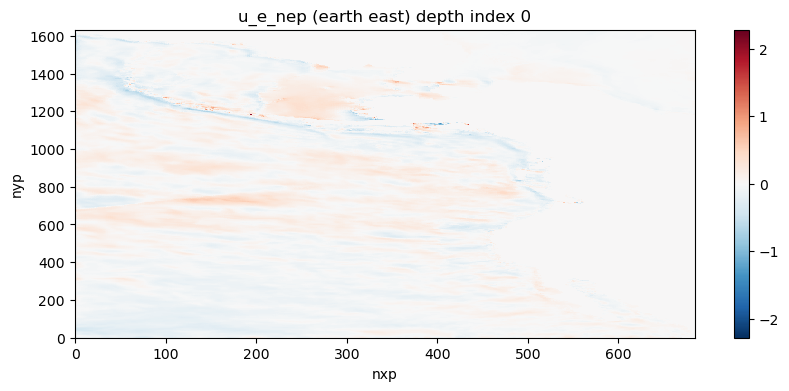

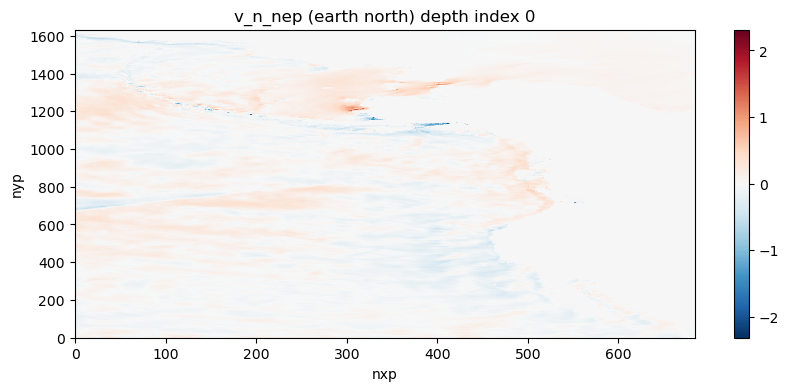

In [20]:
# ## 7) Regrid NEP u/v → NEP supergrid (nearest) and rotate to earth
# Target “supergrid_uv” uses hgrid_nep x/y on (nyp,nxp).
# NOTE: This step’s correctness is critical: check magnitudes and spot-check maps.

# %%
supergrid_uv = xr.Dataset(
    {
        "lon": (("nyp", "nxp"), hgrid_nep["x"].data),
        "lat": (("nyp", "nxp"), hgrid_nep["y"].data),
    }
)
ds_overview(supergrid_uv, "supergrid_uv target")

regrid_u = xe.Regridder(glorys_u, supergrid_uv, method="nearest_s2d",
                        filename="regrid_u_nep.nc", reuse_weights=True)
regrid_v = xe.Regridder(glorys_v, supergrid_uv, method="nearest_s2d",
                        filename="regrid_v_nep.nc", reuse_weights=True)

interp_u = regrid_u(glorys_u[[u_var]])
interp_v = regrid_v(glorys_v[[v_var]])

print("interp_u:", interp_u[u_var].shape, interp_u[u_var].dims)
print("interp_v:", interp_v[v_var].shape, interp_v[v_var].dims)

# Rotate NEP model-aligned (on NEP supergrid) → earth (east,north)
u_e_nep, v_n_nep = rotate_uv_model_to_earth(interp_u[u_var], interp_v[v_var], angle_dx_nep)
def q(da, name):
    v = da.values
    finite = np.isfinite(v)
    print(f"{name:>10} shape={da.shape} finite={finite.mean():.3f} "
          f"min={np.nanmin(v):.3g} p99={np.nanpercentile(v,99):.3g} max={np.nanmax(v):.3g}")

q(interp_u[u_var], "interp_u")
q(interp_v[v_var], "interp_v")
q(u_e_nep, "u_e_nep")
q(v_n_nep, "v_n_nep")


# Normalize dims order for sanity
# (your rotate function returns DataArray; ensure dims match what you expect)
print("u_e_nep dims:", u_e_nep.dims, "shape:", u_e_nep.shape)
print("v_n_nep dims:", v_n_nep.dims, "shape:", v_n_nep.shape)

da_stats(u_e_nep, "u_e_nep")
da_stats(v_n_nep, "v_n_nep")

# Optional quick surface plot (pick k=0)
# %%
k = 0
plt.figure()
u_e_nep.isel(time=0, depth=k).plot()
plt.title(f"u_e_nep (earth east) depth index {k}")
plt.show()

plt.figure()
v_n_nep.isel(time=0, depth=k).plot()
plt.title(f"v_n_nep (earth north) depth index {k}")
plt.show()

In [23]:
# ## 8) Tracers (T/S/SSH): set a clean IC time and vertical interpolate to ztarget
# We keep decode_times=False and set time ourselves from the filename.

# %%
ds1 = xr.open_dataset(glorys_file, decode_times=False)
ds1 = ds1.rename({k:v for k,v in {"Layer":"depth", "Time":"time"}.items() if k in ds1.dims or k in ds1.coords})
tr = ds1[[temp_var, sal_var, ssh_var]]

ic_date = date_from_restart_path(glorys_file)
tr = tr.assign_coords(time=("time", [ic_date]))

ds_overview(tr, "tracers (raw, time forced)")

# vertical interp to zl (extrapolate then ffill)
revert = tr.interp(depth=ztarget, kwargs={"fill_value": "extrapolate"}).ffill("zl", limit=None)
ds_overview(revert, "revert (vertically interped)")


--- tracers (raw, time forced) ---
<xarray.Dataset> Size: 337MB
Dimensions:  (time: 1, depth: 75, lath: 816, lonh: 342)
Coordinates:
  * lath     (lath) float64 7kB 13.86 13.93 14.0 14.07 ... 59.51 59.52 59.52
  * lonh     (lonh) float64 3kB 229.1 229.2 229.3 229.3 ... 254.8 254.9 255.0
  * depth    (depth) float64 600B 1.0 3.0 5.0 ... 5.875e+03 6.125e+03 6.375e+03
  * time     (time) datetime64[s] 8B 1996-01-01
Data variables:
    Temp     (time, depth, lath, lonh) float64 167MB ...
    Salt     (time, depth, lath, lonh) float64 167MB ...
    sfc      (time, lath, lonh) float64 2MB ...
Attributes:
    NumFilesInSet:  1
coord time: dtype=datetime64[s] shape=(1,) example=['1996-01-01T00:00:00']
coord depth: dtype=float64 shape=(75,) example=[1. 3. 5.]
coord lath: dtype=float64 shape=(816,) example=[13.86179733 13.93039322 13.99901676]
coord lonh: dtype=float64 shape=(342,) example=[229.14501953 229.21002197 229.27508545]
data_vars: ['Temp', 'Salt', 'sfc']

--- revert (vertically interp

In [24]:
# ## 9) Flooding over land
# Your `revert` dims are likely (time, zl, lath, lonh). Flood expects ydim/xdim names.
# Use lath/lonh directly, or rename them to yh/xh once here.

# %%
# Option: rename dims once (recommended) to avoid later confusion
rename_map = {}
if "lath" in revert.dims: rename_map["lath"] = "yh"
if "lonh" in revert.dims: rename_map["lonh"] = "xh"
revert2 = revert.rename(rename_map) if rename_map else revert

print("revert2 dims:", revert2.dims)

flooded = xr.merge([
    flood.flood_kara(revert2[temp_var], zdim="zl", ydim="yh", xdim="xh"),
    flood.flood_kara(revert2[sal_var],  zdim="zl", ydim="yh", xdim="xh"),
])

# flood ssh separately (no zl); flood_kara adds a dummy z dim → drop it
flooded[ssh_var] = flood.flood_kara(revert2[ssh_var], ydim="yh", xdim="xh").isel(z=0).drop_vars("z")

ds_overview(flooded, "flooded tracers")

# quick sanity checks
da_stats(flooded[temp_var].isel(time=0, zl=0), "Temp sfc-ish")
da_stats(flooded[sal_var].isel(time=0, zl=0), "Salt sfc-ish")
da_stats(flooded[ssh_var].isel(time=0), "SSH")

revert2 dims: FrozenMappingWarningOnValuesAccess({'yh': 816, 'xh': 342, 'time': 1, 'zl': 75})

--- flooded tracers ---
<xarray.Dataset> Size: 337MB
Dimensions:  (time: 1, zl: 75, yh: 816, xh: 342)
Coordinates:
  * time     (time) datetime64[s] 8B 1996-01-01
  * zl       (zl) float64 600B 1.0 3.0 5.0 7.0 ... 5.875e+03 6.125e+03 6.375e+03
  * yh       (yh) float64 7kB 13.86 13.93 14.0 14.07 ... 59.5 59.51 59.52 59.52
  * xh       (xh) float64 3kB 229.1 229.2 229.3 229.3 ... 254.8 254.9 255.0
Data variables:
    Temp     (time, zl, yh, xh) float64 167MB dask.array<chunksize=(1, 75, 816, 342), meta=np.ndarray>
    Salt     (time, zl, yh, xh) float64 167MB dask.array<chunksize=(1, 75, 816, 342), meta=np.ndarray>
    sfc      (time, yh, xh) float64 2MB dask.array<chunksize=(1, 816, 342), meta=np.ndarray>
coord time: dtype=datetime64[s] shape=(1,) example=['1996-01-01T00:00:00']
coord zl: dtype=float64 shape=(75,) example=[1. 3. 5.]
coord yh: dtype=float64 shape=(816,) example=[13.86179733 13

In [25]:
# ## 10) Load CGOA grid and define target tracer vs target supergrid
# - `target_t`: tracer grid (xh,yh) extracted from supergrid centers
# - `target_uv`: full supergrid (nxp,nyp) for velocity rotation then subsample

# %%
target_grid = xr.open_dataset(grid_file)
ds_overview(target_grid, "CGOA ocean_hgrid (target_grid)")

target_t = (
    target_grid[["x", "y"]]
    .isel(nxp=slice(1, None, 2), nyp=slice(1, None, 2))
    .rename({"x": "lon", "y": "lat", "nxp": "xh", "nyp": "yh"})
)
target_uv = target_grid[["x", "y"]].rename({"x": "lon", "y": "lat"})  # keep (nyp,nxp)

ds_overview(target_t, "target_t (tracer grid)")
ds_overview(target_uv, "target_uv (supergrid)")


--- CGOA ocean_hgrid (target_grid) ---
<xarray.Dataset> Size: 24MB
Dimensions:   (nyp: 1057, nxp: 961, nx: 960, ny: 1056)
Dimensions without coordinates: nyp, nxp, nx, ny
Data variables:
    x         (nyp, nxp) float32 4MB ...
    y         (nyp, nxp) float32 4MB ...
    dx        (nyp, nx) float32 4MB ...
    dy        (ny, nxp) float32 4MB ...
    area      (ny, nx) float32 4MB ...
    angle_dx  (nyp, nxp) float32 4MB ...
    tile      |S5 5B ...
Attributes:
    grid_version:  0.2
    code_version:  ESMG/PyCNAL: heads/python3-0-g5ea501ef90-dirty
    history:       2025-07-25: convert_ROMS_grid_to_MOM6.py /import/AKWATERS/...
data_vars: ['x', 'y', 'dx', 'dy', 'area', 'angle_dx', 'tile']

--- target_t (tracer grid) ---
<xarray.Dataset> Size: 2MB
Dimensions:  (yh: 528, xh: 480)
Dimensions without coordinates: yh, xh
Data variables:
    lon      (yh, xh) float32 1MB ...
    lat      (yh, xh) float32 1MB ...
Attributes:
    grid_version:  0.2
    code_version:  ESMG/PyCNAL: heads/python

In [26]:
# ## 11) Regrid flooded tracers to CGOA tracer grid

# %%
regrid_kws = dict(method="nearest_s2d", reuse_weights=reuse_weights, periodic=False)

glorys_to_t = xe.Regridder(flooded, target_t, filename="regrid_glorys_tracers.nc", **regrid_kws)
interped_t = glorys_to_t(flooded[[temp_var, sal_var, ssh_var]])

ds_overview(interped_t, "interped_t (tracers on CGOA tracer grid)")
print("interped_t time dtype:", interped_t["time"].dtype, interped_t["time"].values)

# %% [markdown]
# ## 12) Regrid earth-relative velocities (u_e, v_n) to CGOA supergrid, then rotate to CGOA model axes

# %%
# NEP supergrid as SOURCE for uv regridder
nep_super = xr.open_dataset(grid_file_nep)[["x", "y"]].rename({"x":"lon", "y":"lat"})
ds_overview(nep_super, "nep_super (source grid for uv)")

glorys_to_uv = xe.Regridder(nep_super, target_uv, filename="regrid_glorys_uv.nc", **regrid_kws)

# ensure u_e_nep/v_n_nep carry the same explicit time as tracers (optional but helps)
u_e_nep2 = u_e_nep.assign_coords(time=("time", [ic_date]))
v_n_nep2 = v_n_nep.assign_coords(time=("time", [ic_date]))

uv_src = xr.Dataset({"u_e": u_e_nep2, "v_n": v_n_nep2})
ds_overview(uv_src, "uv_src (earth-relative on NEP supergrid)")

interped_uv = glorys_to_uv(uv_src)
ds_overview(interped_uv, "interped_uv (earth-relative on CGOA supergrid)")

# Rotate earth-relative -> model-relative on CGOA supergrid
urot, vrot = rotate_uv(interped_uv["u_e"], interped_uv["v_n"], target_grid["angle_dx"])

da_stats(urot, "urot supergrid")
da_stats(vrot, "vrot supergrid")



--- interped_t (tracers on CGOA tracer grid) ---
<xarray.Dataset> Size: 306MB
Dimensions:  (time: 1, zl: 75, yh: 528, xh: 480)
Coordinates:
  * time     (time) datetime64[s] 8B 1996-01-01
  * zl       (zl) float64 600B 1.0 3.0 5.0 7.0 ... 5.875e+03 6.125e+03 6.375e+03
Dimensions without coordinates: yh, xh
Data variables:
    Temp     (time, zl, yh, xh) float64 152MB dask.array<chunksize=(1, 75, 528, 480), meta=np.ndarray>
    Salt     (time, zl, yh, xh) float64 152MB dask.array<chunksize=(1, 75, 528, 480), meta=np.ndarray>
    sfc      (time, yh, xh) float64 2MB dask.array<chunksize=(1, 528, 480), meta=np.ndarray>
Attributes:
    regrid_method:  nearest_s2d
coord time: dtype=datetime64[s] shape=(1,) example=['1996-01-01T00:00:00']
coord zl: dtype=float64 shape=(75,) example=[1. 3. 5.]
data_vars: ['Temp', 'Salt', 'sfc']
interped_t time dtype: datetime64[s] ['1996-01-01T00:00:00']

--- nep_super (source grid for uv) ---
<xarray.Dataset> Size: 9MB
Dimensions:  (nyp: 1633, nxp: 685)
Dime

uo time dtype: datetime64[s] ['1996-01-01T00:00:00']
vo time dtype: datetime64[s] ['1996-01-01T00:00:00']
     uo surf | shape=(528, 481) dtype=float64 finite=1.000 min=-2.011 max=1.215 mean=-0.01655
     vo surf | shape=(529, 480) dtype=float64 finite=1.000 min=-1.966 max=0.8296 mean=0.02765


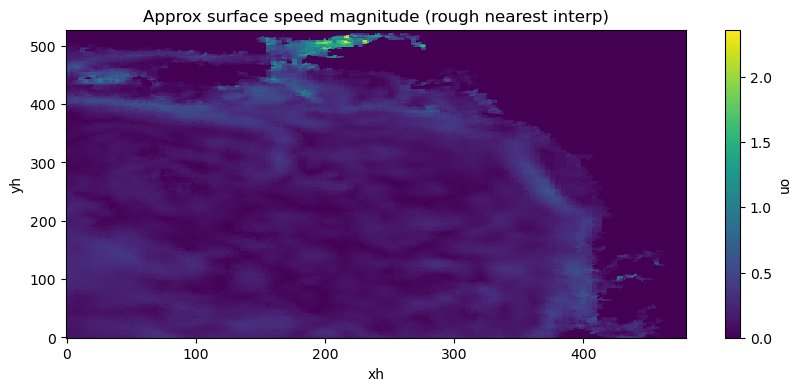

In [27]:
# ## 13) Subsample supergrid velocities to staggered u/v grids and standardize dims
# IMPORTANT: verify you are slicing the correct parity for u and v.

# %%
uo = urot.isel(nxp=slice(0, None, 2), nyp=slice(1, None, 2))
uo = uo.rename({"nxp": "xq", "nyp": "yh", "depth": "zl"}).transpose("time", "zl", "yh", "xq")
uo.name = "uo"

vo = vrot.isel(nxp=slice(1, None, 2), nyp=slice(0, None, 2))
vo = vo.rename({"nxp": "xh", "nyp": "yq", "depth": "zl"}).transpose("time", "zl", "yq", "xh")
vo.name = "vo"

# Force time coord to match tracer time (dtype + value)
uo = uo.assign_coords(time=interped_t["time"])
vo = vo.assign_coords(time=interped_t["time"])

print("uo time dtype:", uo["time"].dtype, uo["time"].values)
print("vo time dtype:", vo["time"].dtype, vo["time"].values)
da_stats(uo.isel(time=0, zl=0), "uo surf")
da_stats(vo.isel(time=0, zl=0), "vo surf")

# Optional vector magnitude quick-check at surface
# %%
spd = np.hypot(
    uo.isel(time=0, zl=0).interp(xq=interped_t["xh"], yh=interped_t["yh"], method="nearest"),
    vo.isel(time=0, zl=0).interp(xh=interped_t["xh"], yq=interped_t["yh"], method="nearest"),
)
plt.figure()
spd.plot()
plt.title("Approx surface speed magnitude (rough nearest interp)")
plt.show()

In [28]:
# ## 14) Merge tracers + velocities and rename to MOM variables

# %%
interped = xr.merge([interped_t, uo, vo])

# (optional) reorder dims just for consistent writing / inspection
# Note: you can only transpose dims that exist; keep it simple:
print(interped)

# rename to MOM expectations
interped = interped.rename({
    temp_var: "temp",
    sal_var:  "salt",
    ssh_var:  "ssh",
    "uo":     "u",
    "vo":     "v",
})

ds_overview(interped, "FINAL interped (pre-write)")

<xarray.Dataset> Size: 611MB
Dimensions:  (time: 1, zl: 75, yh: 528, xh: 480, xq: 481, yq: 529)
Coordinates:
  * time     (time) datetime64[s] 8B 1996-01-01
  * zl       (zl) float64 600B 1.0 3.0 5.0 7.0 ... 5.875e+03 6.125e+03 6.375e+03
Dimensions without coordinates: yh, xh, xq, yq
Data variables:
    Temp     (time, zl, yh, xh) float64 152MB dask.array<chunksize=(1, 75, 528, 480), meta=np.ndarray>
    Salt     (time, zl, yh, xh) float64 152MB dask.array<chunksize=(1, 75, 528, 480), meta=np.ndarray>
    sfc      (time, yh, xh) float64 2MB dask.array<chunksize=(1, 528, 480), meta=np.ndarray>
    uo       (time, zl, yh, xq) float64 152MB 0.02185 0.0218 0.02184 ... 0.0 0.0
    vo       (time, zl, yq, xh) float64 152MB -0.1216 -0.1201 ... 0.0 0.0
Attributes:
    regrid_method:  nearest_s2d

--- FINAL interped (pre-write) ---
<xarray.Dataset> Size: 611MB
Dimensions:  (time: 1, zl: 75, yh: 528, xh: 480, xq: 481, yq: 529)
Coordinates:
  * time     (time) datetime64[s] 8B 1996-01-01
  * zl  

Original dims: ('time', 'depth', 'lath', 'lonh') ('time', 'depth', 'lath', 'lonq')


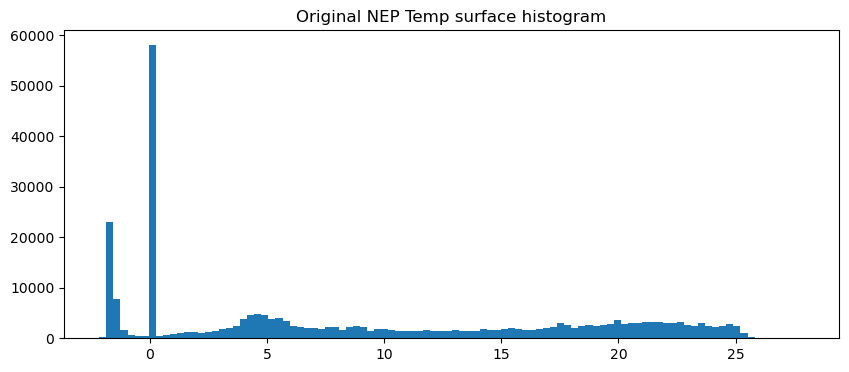

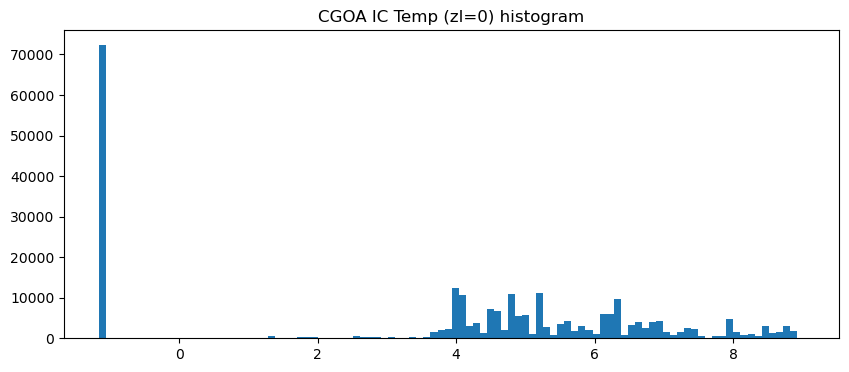

In [29]:
# ## 15) Debug plots: compare against original NEP restart (optional)
# These are crude checks: compare e.g. surface T/S/SSH range, and velocity magnitudes.

# %%
# Original restart fields (surface index assumptions)
# If restart depth dimension name isn't "depth", adapt here.
origT = ds0[temp_var]
origS = ds0[sal_var]
origSSH = ds0[ssh_var]
origU = ds0[u_var]
origV = ds0[v_var]

print("Original dims:", origT.dims, origU.dims)

# Plot histograms (surface)
# %%
plt.figure()
origT.isel(time=0, depth=0).values.ravel()
plt.hist(origT.isel(time=0, depth=0).values.ravel(), bins=100)
plt.title("Original NEP Temp surface histogram")
plt.show()

plt.figure()
interped["temp"].isel(time=0, zl=0).values.ravel()
plt.hist(interped["temp"].isel(time=0, zl=0).values.ravel(), bins=100)
plt.title("CGOA IC Temp (zl=0) histogram")
plt.show()


In [30]:
# ## 16) Write NetCDF (only when you’re satisfied)

# %%
DO_WRITE = True

if DO_WRITE:
    all_vars = list(interped.data_vars) + list(interped.coords)
    enc = {v: {"_FillValue": None} for v in all_vars}

    # If you want MOM-style numeric time, keep this (as in your script),
    # but be aware you’re forcing datetime -> float on write.
    # If you want to keep datetime time, remove this line.
    enc["time"].update({"dtype": "float64", "calendar": "gregorian"})

    interped["zl"].attrs = dict(
        long_name="Layer pseudo-depth, -z*",
        units="meter",
        cartesian_axis="Z",
        positive="down",
    )

    outdir = os.path.dirname(output_file)
    if outdir and not os.path.exists(outdir):
        os.makedirs(outdir)

    interped.to_netcdf(
        output_file,
        format="NETCDF3_64BIT",
        engine="netcdf4",
        encoding=enc,
        unlimited_dims="time",
    )
    print("Wrote:", output_file)

Wrote: /work/Remi.Pages/IC-BC-GOA/CEFI-regional-MOM6/tools/initial/outputs_CGOA/nep_10k_ic_phy_dmi.nc
